In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib import patches
from matplotlib.cm import ScalarMappable
from matplotlib import animation
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from tqdm.notebook import tqdm
from scipy.ndimage import gaussian_filter

import h5py 
import dask.array as da 
from ndcube import NDCube
from image_fourier_filter import filter_solar_timeseries_parallel

In [2]:
file_Halpha_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])

In [3]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_targe_cube_rebin_4 = dkist_vbi_target_cube_crop.rebin((4,4))
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [4]:
halpha_cadence = np.nanmean(np.diff(Halpha_date_obs)).to_value(u.s)
halpha_cadence

6.0933333333333515

In [5]:
Halpha_pr_da_rebin_4 = np.nanmean(Halpha_pr_da.reshape(Halpha_pr_da.shape[0],
                        Halpha_pr_da.shape[1]//4, 4, Halpha_pr_da.shape[2]//4, 4), axis=(2,4))
Halpha_pr_da_rebin_4 = Halpha_pr_da_rebin_4.transpose(1,2,0)
Halpha_pr_da_rebin_4 = Halpha_pr_da_rebin_4.compute()

In [6]:
Halpha_pr_da_rebin_4_filter_5min = filter_solar_timeseries_parallel(Halpha_pr_da_rebin_4, halpha_cadence, 
                                                                    target_period_sec=300.0,)

Filtering 960x960 pixels with 433 time steps using 8 workers...
Using chunk size: 64x64
Created 225 chunks for processing
Progress: 22/225 chunks (9.8%) - Elapsed: 1.6s, ETA: 15.0s
Progress: 44/225 chunks (19.6%) - Elapsed: 2.7s, ETA: 11.2s
Progress: 66/225 chunks (29.3%) - Elapsed: 3.9s, ETA: 9.4s
Progress: 88/225 chunks (39.1%) - Elapsed: 5.1s, ETA: 7.9s
Progress: 110/225 chunks (48.9%) - Elapsed: 6.2s, ETA: 6.5s
Progress: 132/225 chunks (58.7%) - Elapsed: 7.4s, ETA: 5.2s
Progress: 154/225 chunks (68.4%) - Elapsed: 8.6s, ETA: 4.0s
Progress: 176/225 chunks (78.2%) - Elapsed: 9.7s, ETA: 2.7s
Progress: 198/225 chunks (88.0%) - Elapsed: 10.9s, ETA: 1.5s
Progress: 220/225 chunks (97.8%) - Elapsed: 12.0s, ETA: 0.3s
Filtering completed in 12.31 seconds


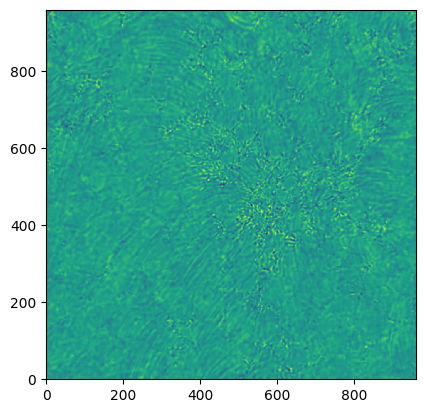

In [7]:
fig, ax = plt.subplots()
ax.imshow(Halpha_pr_da_rebin_4_filter_5min[:,:,100], origin="lower", interpolation="none",)
        #   norm=ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(0.6)))

Filtering 960x960 pixels with 433 time steps using 8 workers...
Using chunk size: 64x64
Created 225 chunks for processing
Progress: 22/225 chunks (9.8%) - Elapsed: 2.2s, ETA: 19.9s
Progress: 44/225 chunks (19.6%) - Elapsed: 3.2s, ETA: 13.2s
Progress: 66/225 chunks (29.3%) - Elapsed: 4.3s, ETA: 10.4s
Progress: 88/225 chunks (39.1%) - Elapsed: 5.4s, ETA: 8.3s
Progress: 110/225 chunks (48.9%) - Elapsed: 6.5s, ETA: 6.8s
Progress: 132/225 chunks (58.7%) - Elapsed: 7.6s, ETA: 5.4s
Progress: 154/225 chunks (68.4%) - Elapsed: 8.7s, ETA: 4.0s
Progress: 176/225 chunks (78.2%) - Elapsed: 9.8s, ETA: 2.7s
Progress: 198/225 chunks (88.0%) - Elapsed: 10.8s, ETA: 1.5s
Progress: 220/225 chunks (97.8%) - Elapsed: 11.9s, ETA: 0.3s
Filtering completed in 12.32 seconds


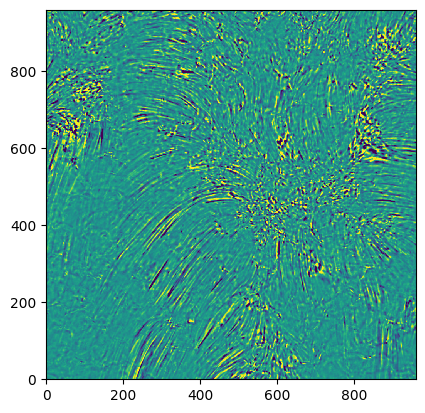

In [47]:
Halpha_pr_da_rebin_4_filter_test = filter_solar_timeseries_parallel(Halpha_pr_da_rebin_4, halpha_cadence, 
                                                                    target_period_sec=60.0,
                                                                    filter_width_sec=10.0,
                                                                    filter_type="highpass")
fig, ax = plt.subplots()
ax.imshow(Halpha_pr_da_rebin_4_filter_test[:,:,100], origin="lower", interpolation="none",
          norm=ImageNormalize(vmin=np.nanpercentile(Halpha_pr_da_rebin_4_filter_test[:,:,100], 1),
          vmax=np.nanpercentile(Halpha_pr_da_rebin_4_filter_test[:,:,100], 99)))

In [48]:
def storeSequence(data, movieName, dpi=300, write=True, fps=30):
  fig =plt.figure(figsize=(5,5))
  im = plt.imshow(data[:,:,0], cmap='gray', interpolation='none', origin="lower",
                  norm=ImageNormalize(vmin=np.nanpercentile(data[:,:,0], 1), vmax=np.nanpercentile(data[:,:,0], 99),
                  stretch=AsinhStretch(0.2)))
  fig.tight_layout()


  def animate(n):
    im.set_data(data[:,:,n])
    return im

  ani = animation.FuncAnimation(fig, animate, frames=data.shape[-1], interval=100)
  
  if write:
    writer = animation.writers['ffmpeg'](fps=fps)
    ani.save(movieName, writer=writer, dpi=dpi)
  plt.close(fig) 

In [9]:
storeSequence(Halpha_pr_da_rebin_4_filter_5min, "../../figs/test_movie/Halpha_pr_da_rebin_4_filter_5min.mp4",
              )

In [19]:
storeSequence(Halpha_pr_da_rebin_4_filter_test, "../../figs/test_movie/Halpha_pr_da_rebin_4_filter_highpass_1min.mp4",
              )

In [43]:
Halpha_gaussian_filter_test = Halpha_pr_da_rebin_4[:,:,100] + 10*(Halpha_pr_da_rebin_4[:,:,100] - gaussian_filter(Halpha_pr_da_rebin_4[:,:,100], sigma=5.0))

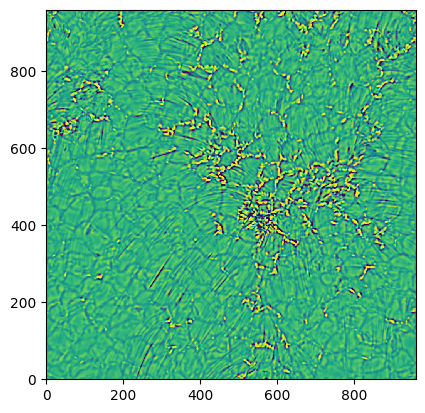

In [44]:
fig, ax = plt.subplots()
ax.imshow(Halpha_gaussian_filter_test, origin="lower", interpolation="none",
          norm=ImageNormalize(vmin=np.nanpercentile(Halpha_gaussian_filter_test, 1),
          vmax=np.nanpercentile(Halpha_gaussian_filter_test, 99),
          stretch=AsinhStretch(0.2)))